In [61]:
from pathlib import Path
import numpy as np
import pandas as pd
rng = np.random.default_rng(404)
n = 300
cols = ['visits', 'recency', 'engagement', 'spend']
x = rng.normal(size=(n, 4))
group = rng.choice(["G1", "G2"], size=n)
score = x @ np.array([0.6, -0.9, 1.1, 0.4])
score += 0.4 * (group == "G2") + rng.normal(0, 1, n)
y = (score > 0).astype(int)
df = pd.DataFrame(np.round(50 + 10*x, 2), columns=cols)
df.insert(0, "record_id", np.arange(1, n+1))
df["group"] = group
df["response"] = y
for col in cols[:2]:
    df.loc[rng.choice(n, 15, replace=False), col] = np.nan
df = pd.concat([df, df.iloc[:5]], ignore_index=True)
Path("data/raw").mkdir(parents=True, exist_ok=True)
df.to_csv("data/raw/set_d.csv", index=False)


In [62]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [63]:
df.head(10)    

,record_id,visits,recency,engagement,spend,group,response
0,1,53.96,43.84,54.57,58.93,G2,1
1,2,NaN,49.75,52.97,63.64,G2,1
2,3,35.39,66.52,44.98,47.33,G2,0
3,4,45.01,42.80,47.62,54.48,G1,1
4,5,53.84,53.72,48.33,58.30,G2,1
5,6,39.37,NaN,52.60,57.58,G1,0
6,7,61.43,27.88,48.64,47.60,G1,1
7,8,NaN,30.53,59.06,60.53,G1,0
8,9,55.95,51.53,45.87,51.03,G1,0
9,10,50.30,18.90,57.69,61.16,G2,1


In [64]:
df.describe()

,record_id,visits,recency,engagement,spend,response
count,305.000000,289.000000,290.000000,305.000000,305.000000,305.000000
mean,148.081967,49.293599,49.950724,50.903213,49.922984,0.580328
std,88.052447,9.846792,9.687006,10.479720,10.134986,0.494316
min,1.000000,20.320000,18.900000,23.130000,5.070000,0.000000
25%,72.000000,42.620000,43.437500,43.890000,42.930000,0.000000
50%,148.000000,49.400000,49.695000,51.240000,50.280000,1.000000
75%,224.000000,55.950000,55.902500,57.260000,57.200000,1.000000
max,300.000000,75.810000,81.170000,81.990000,79.710000,1.000000


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 305 entries, 0 to 304
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   record_id   305 non-null    int64  
 1   visits      289 non-null    float64
 2   recency     290 non-null    float64
 3   engagement  305 non-null    float64
 4   spend       305 non-null    float64
 5   group       305 non-null    object 
 6   response    305 non-null    int64  
dtypes: float64(4), int64(2), object(1)
memory usage: 16.8+ KB


In [66]:
df.shape

(305, 7)

In [67]:
df.isnull().sum()

record_id      0
visits        16
recency       15
engagement     0
spend          0
group          0
response       0
dtype: int64

# M1 — DESCRIPTIVE STATISTICS

Observed engagement statistics:


,value
n_observed,300.000000
mean,50.923367
median,51.260000
sample_std_ddof1,10.555845


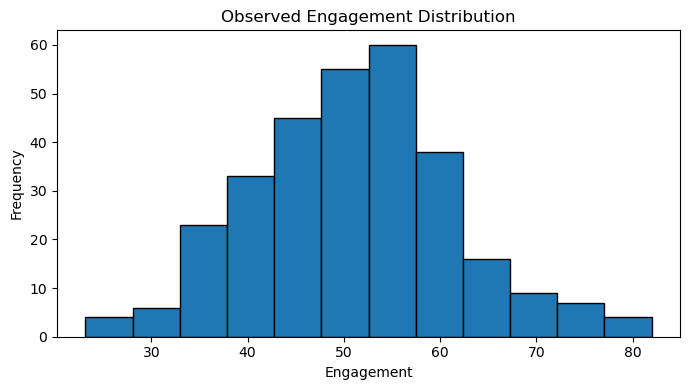

In [68]:
# Deduplicate first. Do NOT impute engagement for descriptive statistics.
clean = df.drop_duplicates().copy()

engagement_observed = clean["engagement"].dropna()

m1 = pd.Series({
    "n_observed": engagement_observed.size,
    "mean": engagement_observed.mean(),
    "median": engagement_observed.median(),
    "sample_std_ddof1": engagement_observed.std(ddof=1),
})

print("Observed engagement statistics:")
display(m1.to_frame("value"))

plt.figure(figsize=(7, 4))
plt.hist(engagement_observed, bins=12, edgecolor="black")
plt.title("Observed Engagement Distribution")
plt.xlabel("Engagement")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### M3 — Linear algebra: covariance, eigenvalues/eigenvectors

In [69]:
# Use complete rows for visits and engagement; center each variable before covariance.
cov_data = clean[["visits", "engagement"]].dropna().to_numpy()
centered = cov_data - cov_data.mean(axis=0)

cov_matrix = np.cov(centered, rowvar=False, ddof=1)
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# Sort from largest to smallest eigenvalue.
order = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

variance_share = eigenvalues / eigenvalues.sum()


In [70]:
print("Sample covariance matrix:")
display(pd.DataFrame(cov_matrix, index=["visits", "engagement"], columns=["visits", "engagement"]))

print("Eigenvalues:", eigenvalues)
print("Eigenvectors (columns):")
display(pd.DataFrame(eigenvectors, index=["visits", "engagement"],
                     columns=["PC1", "PC2"]))
print("Variance share:", variance_share)

print(f"Principal direction (PC1) = [{eigenvectors[0,0]:.6f}, {eigenvectors[1,0]:.6f}]")
print(f"PC1 variance share = {variance_share[0]:.4%}")

Sample covariance matrix:


,visits,engagement
visits,97.429200,2.775987
engagement,2.775987,108.146746


Eigenvalues: [108.82308247  96.75286276]
Eigenvectors (columns):


,PC1,PC2
visits,0.236714,-0.971579
engagement,0.971579,0.236714


Variance share: [0.52935708 0.47064292]
Principal direction (PC1) = [0.236714, 0.971579]
PC1 variance share = 52.9357%


## Task 2 — Data Preprocessing & Feature Engineering

### F1 — Audit and partition

In [71]:
print("Raw shape:", df.shape)
print("\nExact duplicate rows:", int(df.duplicated().sum()))
print("\nMissing values in raw data:")
display(df.isna().sum().to_frame("missing_count"))

Raw shape: (305, 7)

Exact duplicate rows: 5

Missing values in raw data:


,missing_count
record_id,0
visits,16
recency,15
engagement,0
spend,0
group,0
response,0


In [75]:
print("Raw shape:", df.shape)
print("\nExact duplicate rows:", int(df.duplicated().sum()))
print("\nMissing values in raw data:")
display(df.isna().sum().to_frame("missing_count"))

print("\nRaw target counts:")
display(df["response"].value_counts().sort_index().to_frame("count"))

clean = df.drop_duplicates().copy()

print("\nAfter exact deduplication:")
print("Shape:", clean.shape)
print("Unique record IDs:", clean["record_id"].nunique())
print("Duplicate IDs:", int(clean["record_id"].duplicated().sum()))

assert clean.shape[0] == 300, "The supplied generator should produce 300 unique records."
assert clean["record_id"].is_unique, "record_id must be unique after deduplication."


Raw shape: (305, 7)

Exact duplicate rows: 5

Missing values in raw data:


,missing_count
record_id,0
visits,16
recency,15
engagement,0
spend,0
group,0
response,0



Raw target counts:


,count
response,
0,128
1,177



After exact deduplication:
Shape: (300, 7)
Unique record IDs: 300
Duplicate IDs: 0
